In [1]:
import os
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import sklearn as sk
import matplotlib
from scgen.file_utils import ensure_dir
matplotlib.rc('ytick', labelsize=14)
matplotlib.rc('xtick', labelsize=14)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-22 01:43:00.265048: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 01:43:00.361961: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 10/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
train = scgen.load_file('../data/pancreas.h5ad')
train.obs["cell_type"] = train.obs["celltype"].tolist()
train

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain', 'cell_type'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [4]:
top_cell_types = train.obs["cell_type"].value_counts().index.tolist()[:7]
top_cell_types.remove("not applicable")
train.obs["cell_type"] = "others"
for cell_type in top_cell_types:
    train.obs.loc[train.obs["celltype"] == cell_type, "cell_type"] = cell_type
train.obs["cell_type"].unique()

array(['acinar', 'beta', 'delta', 'others', 'ductal', 'alpha', 'gamma'],
      dtype=object)

In [5]:
train.obs.groupby(['cell_type']).size()

cell_type
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2465
dtype: int64

In [6]:
train.obs.groupby(['sample']).size()

/tmp/ipykernel_42931/139782276.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.obs.groupby(['sample']).size()


sample
Baron          8569
Muraro         2126
Segerstolpe    3363
Wang            635
dtype: int64

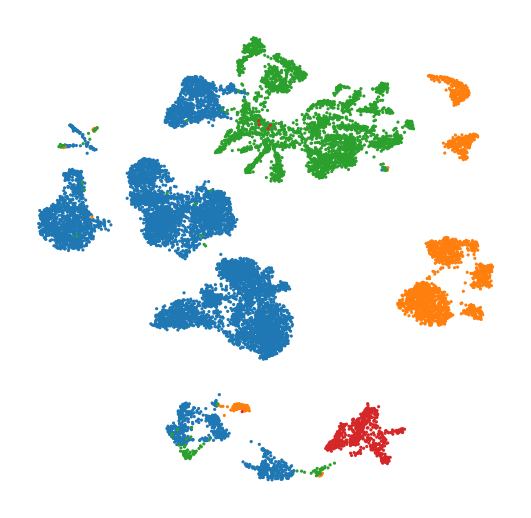

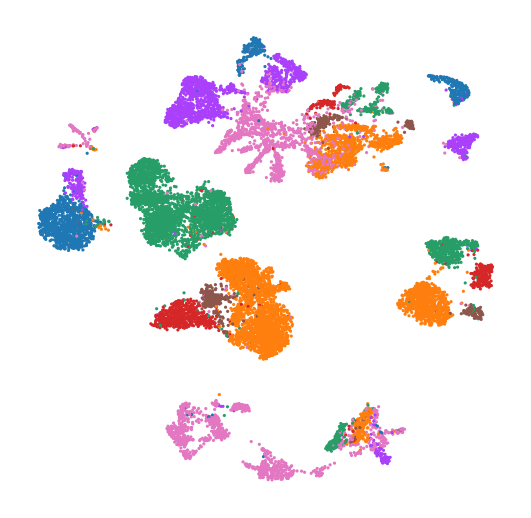

In [7]:
sc.tl.pca(train, svd_solver='arpack')
train.obsm["X_pca"] *= -1
sc.pp.neighbors(train)
sc.tl.umap(train)
sc.pl.umap(train, color=["sample"], title="", frameon=False, legend_loc=None, wspace=.5, show=False, save="_batch.png")
sc.pl.umap(train, color=["sample"], title="", frameon=False, legend_loc=None, wspace=.5, show=True, save="_batch.pdf")
sc.pl.umap(train, color=["cell_type"], title="", frameon=False, legend_loc=None, wspace=.5, show=False, save="_celltype.png")
sc.pl.umap(train, color=["cell_type"], title="", frameon=False, legend_loc=None, wspace=.5, show=True, save="_celltype.pdf")
os.rename(src=os.path.join(path_to_save, "umap_batch.png"),
          dst=os.path.join(path_to_save, "SupplFig10a_umap_batch_original.png"))
os.rename(src=os.path.join(path_to_save, "umap_batch.pdf"),
          dst=os.path.join(path_to_save, "SupplFig10a_umap_batch_original.pdf"))
os.rename(src=os.path.join(path_to_save, "umap_celltype.png"),
          dst=os.path.join(path_to_save, "SupplFig10a_umap_celltype_original.png"))
os.rename(src=os.path.join(path_to_save, "umap_celltype.pdf"),
          dst=os.path.join(path_to_save, "SupplFig10a_umap_celltype_original.pdf"))

In [8]:
X_pca = train.obsm["X_pca"]
labels = train.obs["batch"].tolist()
print(f" average silhouette_score for original data : {sk.metrics.silhouette_score(X_pca, labels)}")

 average silhouette_score for original data : 0.21305908262729645


In [9]:
# Run with the same Python as this kernel (conda env)
import subprocess
import sys
subprocess.check_call([sys.executable, "../code/pancreas.py"])

2026-02-22 01:43:53.296593: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 01:43:53.392618: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-22 01:43:53.392656: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-22 01:43:53.413646: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026

Reconstruction output already exists, skipping: ../data/reconstructed/scGen/pancreas.h5ad


0

In [10]:
pancreas_batched = scgen.load_file('../data/reconstructed/scGen/pancreas.h5ad')
pancreas_batched.obs["cell_type"] = train.obs["celltype"].tolist()
pancreas_batched

AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'cell_type', 'study', 'celltype'

In [11]:
pancreas_batched.obs.groupby(['celltype']).size()

/tmp/ipykernel_42931/3145099751.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pancreas_batched.obs.groupby(['celltype']).size()


celltype
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2465
dtype: int64

In [12]:
pancreas_batched.obs.groupby(['study']).size()

/tmp/ipykernel_42931/1783239266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pancreas_batched.obs.groupby(['study']).size()


study
Baron          8569
Muraro         2126
Segerstolpe    3363
Wang            635
dtype: int64

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

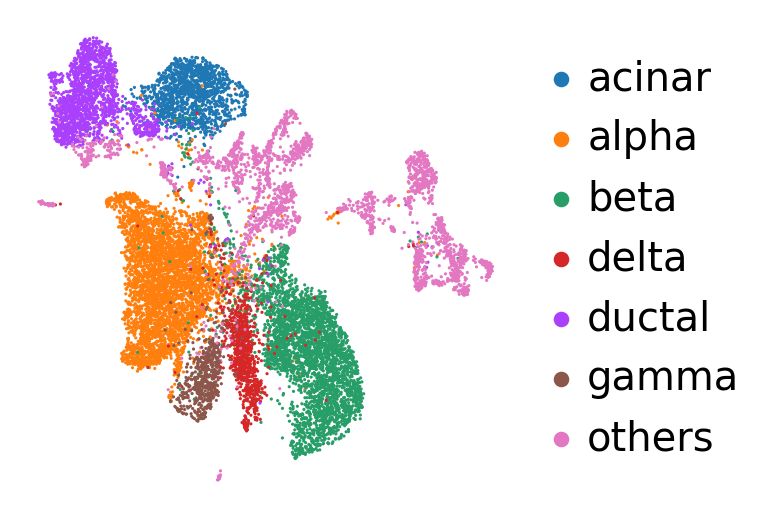

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

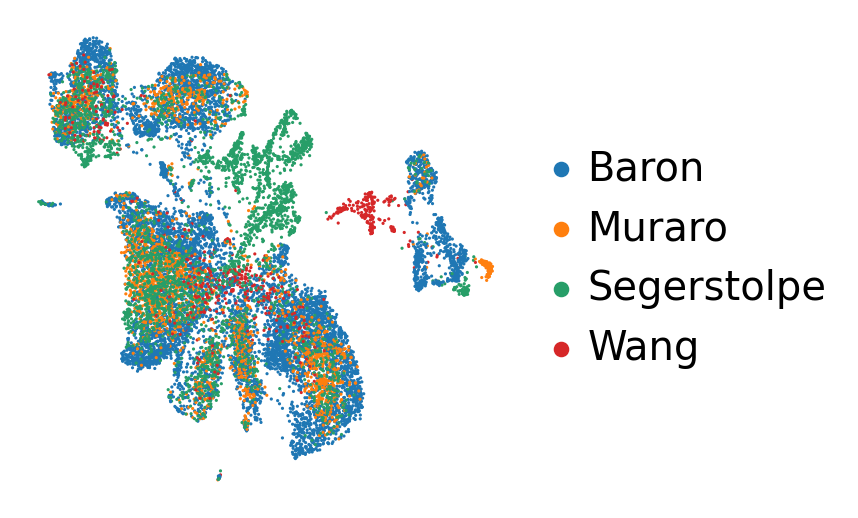

In [13]:
sc.tl.pca(pancreas_batched, svd_solver='arpack')
pancreas_batched.obsm["X_pca"] *= -1
sc.pp.neighbors(pancreas_batched)
sc.tl.umap(pancreas_batched)
sc.pl.umap(pancreas_batched, title="", palette=matplotlib.rcParams["axes.prop_cycle"], color=["celltype"],
           save="_pancreas_cell_batched.png", frameon=False, show=False, legend_fontsize=18)
sc.pl.umap(pancreas_batched, title="", palette=matplotlib.rcParams["axes.prop_cycle"], color=["celltype"],
           save="_pancreas_cell_batched.pdf", frameon=False, show=True, legend_fontsize=18)
sc.pl.umap(pancreas_batched, title="", palette=matplotlib.rcParams["axes.prop_cycle"], color=["study"],
           save="_study_pancreas_batched.png", frameon=False, show=False, legend_fontsize=18)
sc.pl.umap(pancreas_batched, title="", palette=matplotlib.rcParams["axes.prop_cycle"], color=["study"],
           save="_study_pancreas_batched.pdf", frameon=False, show=True, legend_fontsize=18)
os.rename(src=os.path.join(path_to_save, "umap_pancreas_cell_batched.pdf"),
          dst=os.path.join(path_to_save, "SupplFig10b_umap_scgen_celltype.pdf"))
os.rename(src=os.path.join(path_to_save, "umap_study_pancreas_batched.pdf"),
          dst=os.path.join(path_to_save, "SupplFig10b_umap_scgen_batch.pdf"))
os.rename(src=os.path.join(path_to_save, "umap_pancreas_cell_batched.png"),
          dst=os.path.join(path_to_save, "SupplFig10b_umap_scgen_celltype.png"))
os.rename(src=os.path.join(path_to_save, "umap_study_pancreas_batched.png"),
          dst=os.path.join(path_to_save, "SupplFig10b_umap_scgen_batch.png"))

In [14]:
X_pca = pancreas_batched.obsm["X_pca"]
labels = pancreas_batched.obs["study"].tolist()
print(f" average silhouette_score for scGen : {sk.metrics.silhouette_score(X_pca, labels)}")

 average silhouette_score for scGen : -0.06317081302404404


In [15]:
bbknn = scgen.load_file("../data/bbknn.h5ad")
top_cell_types = bbknn.obs["celltype"].value_counts().index.tolist()[:7]
top_cell_types.remove("not applicable")
bbknn.obs["cell_type"] = "others"
for cell_type in top_cell_types:
    bbknn.obs.loc[bbknn.obs["celltype"] == cell_type, "cell_type"] = cell_type
bbknn.obs["cell_type"].unique()

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


array(['acinar', 'beta', 'delta', 'others', 'ductal', 'alpha', 'gamma'],
      dtype=object)

In [16]:
bbknn.obs.groupby(['cell_type']).size()

cell_type
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2465
dtype: int64

In [17]:
bbknn.obs.groupby(['sample']).size()

/tmp/ipykernel_42931/292411932.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bbknn.obs.groupby(['sample']).size()


sample
Baron          8569
Muraro         2126
Segerstolpe    3363
Wang            635
dtype: int64

In [18]:
sc.tl.umap(bbknn)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


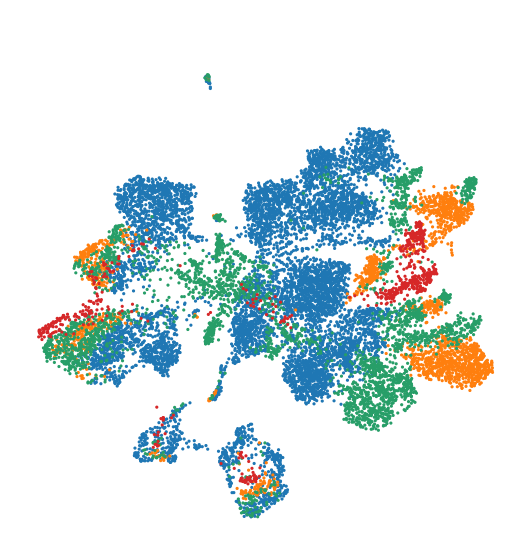

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


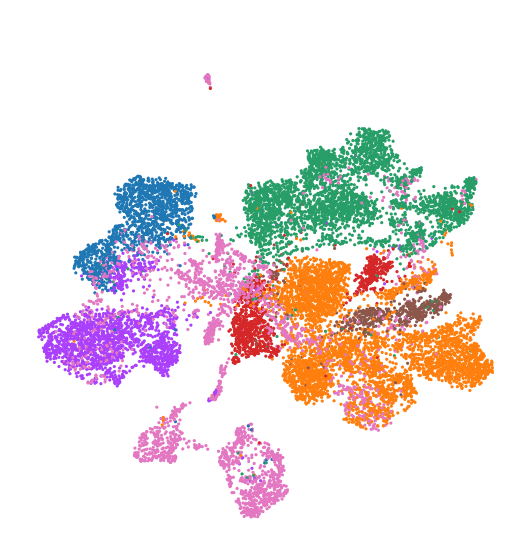

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


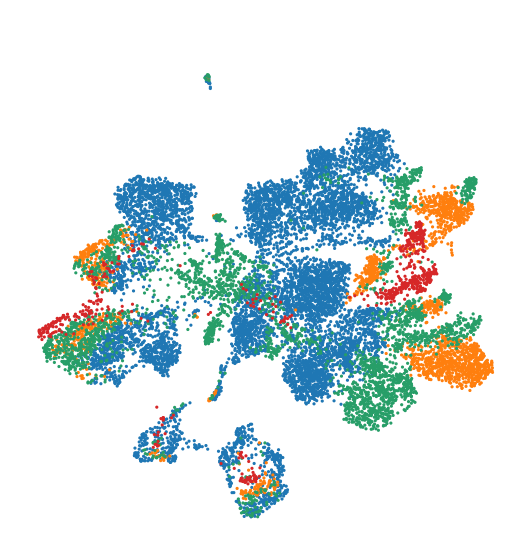

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


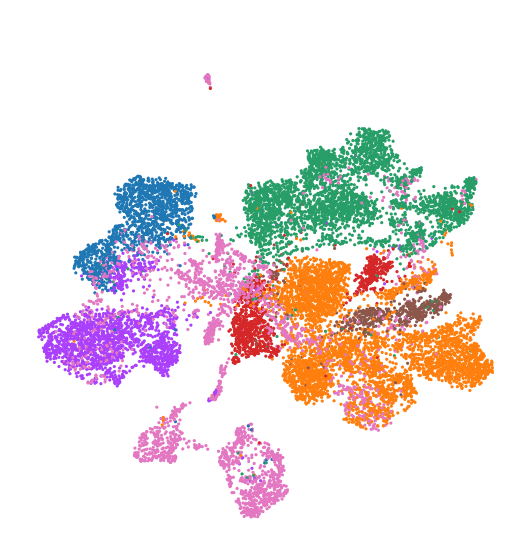

In [19]:
sc.pl.umap(bbknn, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_bbknn_batch.png", frameon=False, title=" ")
sc.pl.umap(bbknn, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_bbknn_celltype.png", frameon=False,  title=" ")

sc.pl.umap(bbknn, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_bbknn_batch.pdf", frameon=False, title=" ")
sc.pl.umap(bbknn, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_bbknn_celltype.pdf", frameon=False,  title=" ")

In [20]:
cca = scgen.load_file("../data/cca.h5ad")
top_cell_types = cca.obs["celltype"].value_counts().index.tolist()[:7]
top_cell_types.remove("not applicable")
cca.obs["cell_type"] = "others"
for cell_type in top_cell_types:
    cca.obs.loc[cca.obs["celltype"] == cell_type, "cell_type"] = cell_type
cca.obs["cell_type"].unique()

array(['acinar', 'beta', 'delta', 'others', 'ductal', 'alpha', 'gamma'],
      dtype=object)

In [21]:
cca.obs.groupby(['cell_type']).size()

cell_type
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2465
dtype: int64

In [22]:
cca.obs.groupby(['sample']).size()

/tmp/ipykernel_42931/3838991653.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cca.obs.groupby(['sample']).size()


sample
Baron          8569
Muraro         2126
Segerstolpe    3363
Wang            635
dtype: int64

In [23]:
sc.pp.neighbors(cca)
sc.tl.umap(cca)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

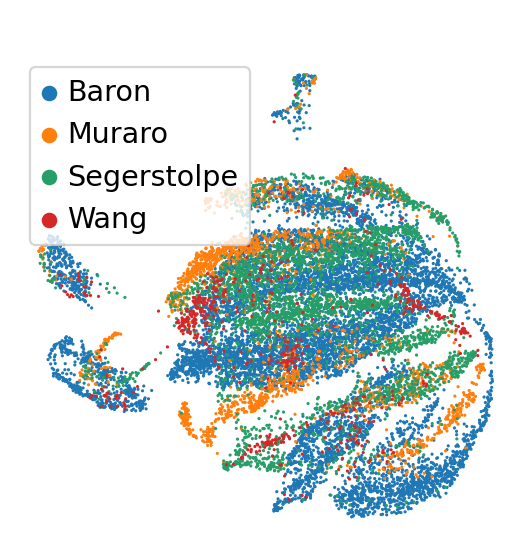

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

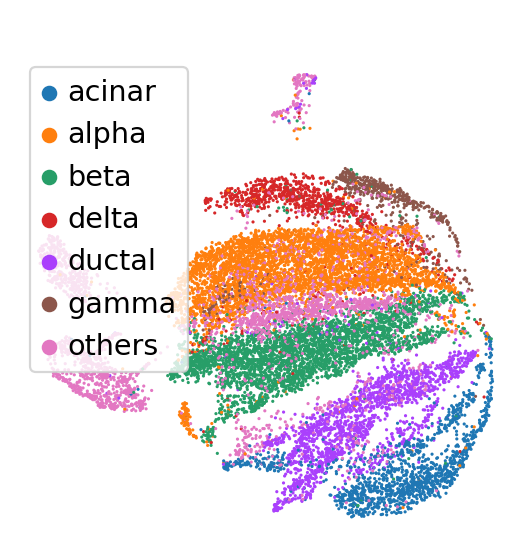

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

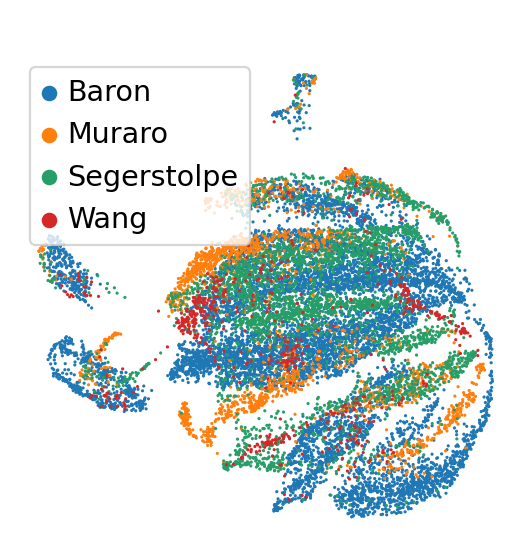

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

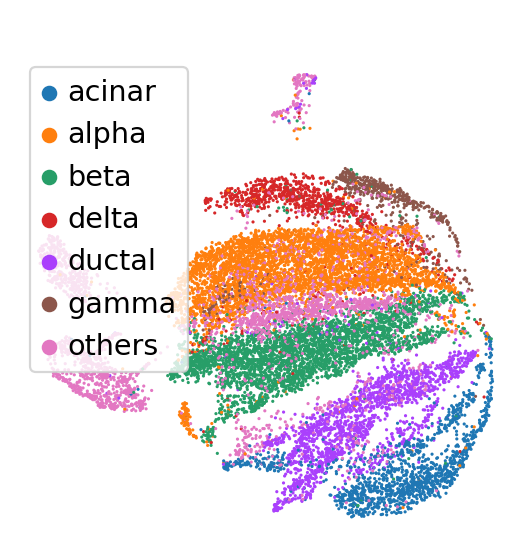

In [24]:
sc.pl.umap(cca, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc=False,  save="_cca_batch.png", frameon=False, title=" ")
sc.pl.umap(cca, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc=False, save="_cca_celltype.png", frameon=False,  title=" ")

sc.pl.umap(cca, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc=False,  save="_cca_batch.pdf", frameon=False, title=" ")
sc.pl.umap(cca, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc=False, save="_cca_celltype.pdf", frameon=False,  title=" ")

In [25]:
X = cca.obsm["X_pca"]
labels = cca.obs["batch"].tolist()
print(f"average silhouette_score for cca : {sk.metrics.silhouette_score(X,labels)}")

average silhouette_score for cca : -0.0009046235353765689


In [26]:
MNN = scgen.load_file("../data/mnn.h5ad")
top_cell_types = MNN.obs["celltype"].value_counts().index.tolist()[:7]
top_cell_types.remove("not applicable")
MNN.obs["cell_type"] = "others"
for cell_type in top_cell_types:
    MNN.obs.loc[MNN.obs["celltype"] == cell_type, "cell_type"] = cell_type
MNN.obs["cell_type"].unique()

array(['acinar', 'beta', 'delta', 'others', 'ductal', 'alpha', 'gamma'],
      dtype=object)

In [27]:
MNN.obs.groupby(['cell_type']).size()

cell_type
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2465
dtype: int64

In [28]:
MNN.obs.groupby(['sample']).size()

/tmp/ipykernel_42931/2221945106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  MNN.obs.groupby(['sample']).size()


sample
Baron          8569
Muraro         2126
Segerstolpe    3363
Wang            635
dtype: int64

In [29]:
sc.tl.pca(MNN, svd_solver='arpack')
MNN.obsm['X_pca'] *= -1  # multiply by -1 to match Seurat
sc.pp.neighbors(MNN)
sc.tl.umap(MNN)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


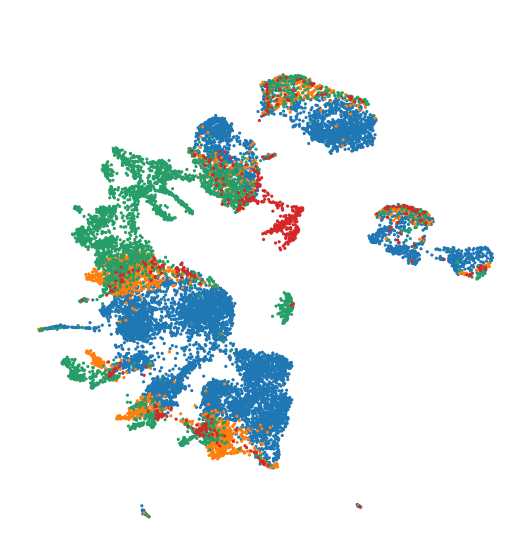

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


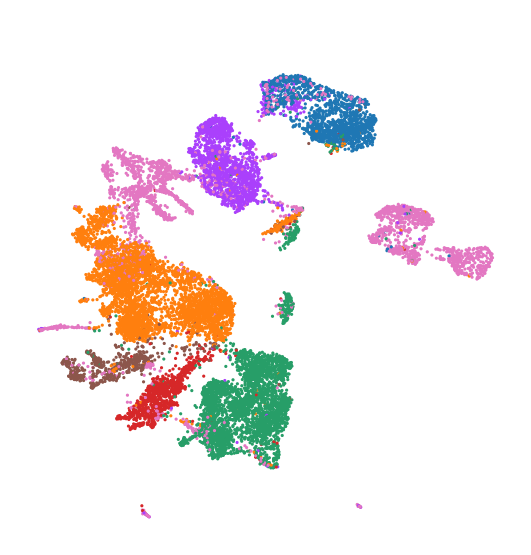

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


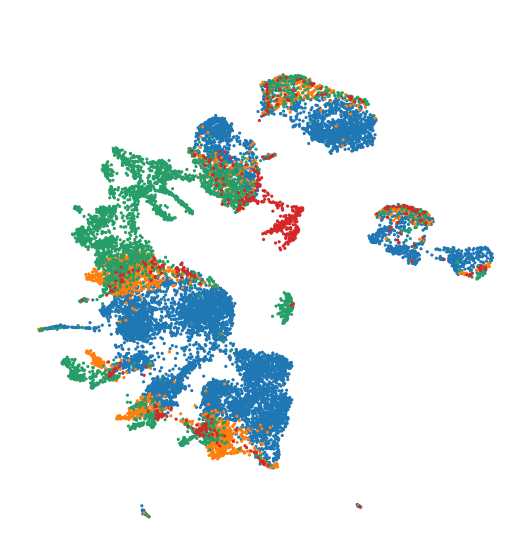

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


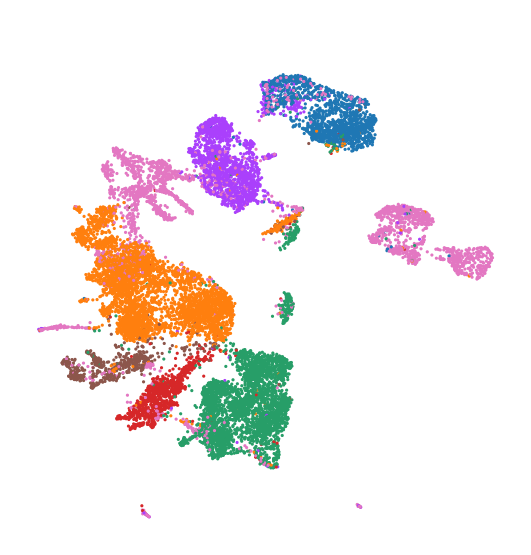

In [30]:
sc.pl.umap(MNN, color="batch", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_mnn_batch.png", frameon=False, title=" ")
sc.pl.umap(MNN, color="cell_type", legend_loc='none', save="_mnn_celltype.png", frameon=False,  title=" ")

sc.pl.umap(MNN, color="batch", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_mnn_batch.pdf", frameon=False, title=" ")
sc.pl.umap(MNN, color="cell_type", legend_loc='none', save="_mnn_celltype.pdf", frameon=False,  title=" ")

In [31]:
X = MNN.obsm["X_pca"]
labels = MNN.obs["batch"].tolist()
print(f"average silhouette_score for MNN : {sk.metrics.silhouette_score(X,labels)}")

average silhouette_score for MNN : 0.00874113105237484


In [32]:
scanorama = scgen.load_file("../data/scanorama.h5ad")
top_cell_types = scanorama.obs["celltype"].value_counts().index.tolist()[:7]
top_cell_types.remove("not applicable")
scanorama.obs["cell_type"] = "others"
for cell_type in top_cell_types:
    scanorama.obs.loc[scanorama.obs["celltype"] == cell_type, "cell_type"] = cell_type
scanorama.obs["cell_type"].unique()

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


array(['acinar', 'beta', 'delta', 'others', 'ductal', 'alpha', 'gamma'],
      dtype=object)

In [33]:
scanorama.obs.groupby(['cell_type']).size()

cell_type
acinar    1368
alpha     4214
beta      3354
delta      917
ductal    1804
gamma      571
others    2089
dtype: int64

In [34]:
scanorama.obs.groupby(['sample']).size()

/tmp/ipykernel_42931/572391234.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scanorama.obs.groupby(['sample']).size()


sample
Baron          8569
Muraro         2126
Segerstolpe    2987
Wang            635
dtype: int64

In [35]:
sc.tl.pca(scanorama, svd_solver='arpack')
scanorama.obsm['X_pca'] *= -1  # multiply by -1 to match Seurat
sc.pp.neighbors(scanorama)
sc.tl.umap(scanorama)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


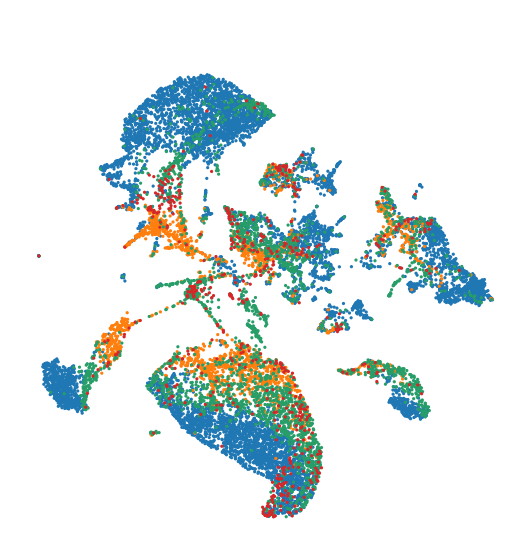

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


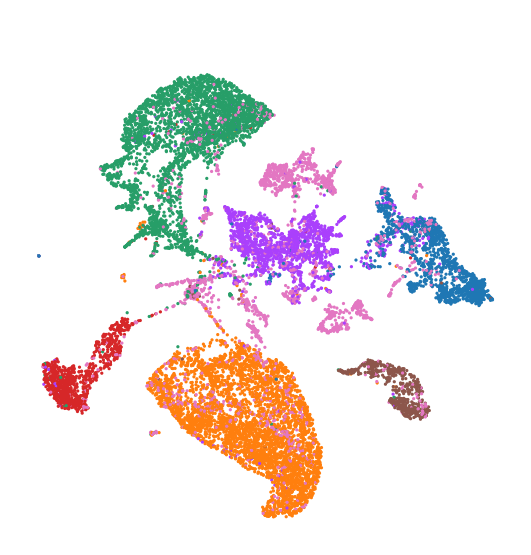

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


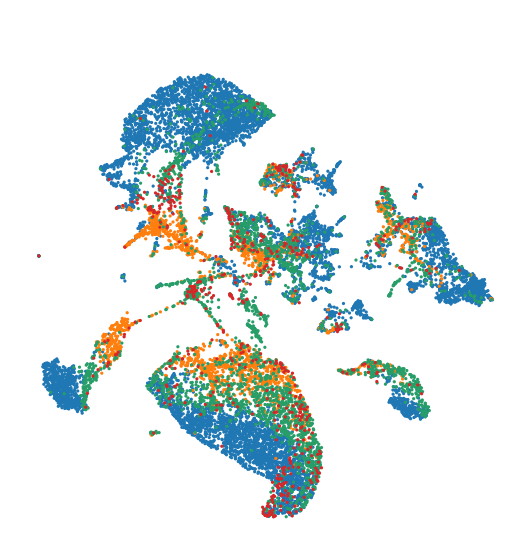

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


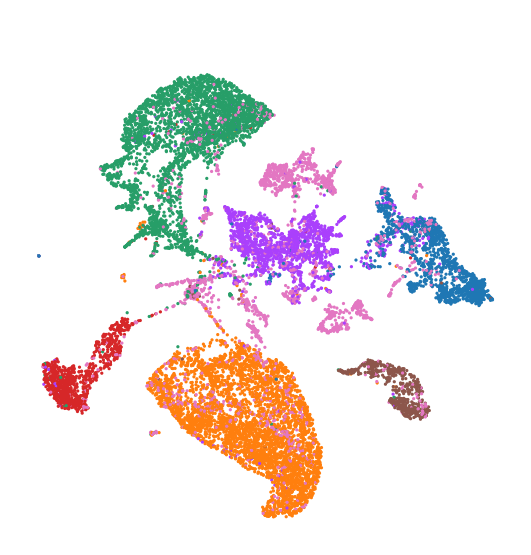

In [36]:
sc.pl.umap(scanorama, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_scanorama_batch.png", frameon=False, title=" ")
sc.pl.umap(scanorama, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_scanorama_celltype.png", frameon=False,  title=" ")

sc.pl.umap(scanorama, color="sample", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_scanorama_batch.pdf", frameon=False, title=" ")
sc.pl.umap(scanorama, color="cell_type", palette=matplotlib.rcParams["axes.prop_cycle"], legend_loc='none', save="_scanorama_celltype.pdf", frameon=False,  title=" ")

In [37]:
X = scanorama.obsm["X_pca"]
labels = scanorama.obs["batch"].tolist()
print(f"average silhouette_score for scanorama : {sk.metrics.silhouette_score(X,labels)}")

average silhouette_score for scanorama : -0.007466030307114124
